- Implement Harris Corner Detector
- Display detected corners on images
- Analyze effect of threshold tuning

In [30]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from modules.data_loader import load_data
from modules.preprocessing import standardize

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data
X_train = [standardize(img) for img in X_train]
X_test = [standardize(img) for img in X_test]

In [ ]:
# Harris detects pixels where the image intensity changes strongly 
# in both horizontal and vertical directions,
# which correspond to structurally significant points called corners.

def apply_harris(img, threshold):
    # Convert to float32
    gray = np.float32(img)
    
    # Apply Harris corner detection
    harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    
    # Result is dilated to enhance the corner points
    harris = cv2.dilate(harris, None)
    
    # Threshold 
    output = img.copy()
    output[harris > threshold * harris.max()] = 255
    num_corners = np.sum(harris > threshold * harris.max())
    print(num_corners)
    
    return output, harris

2783
1683
1287
980
822


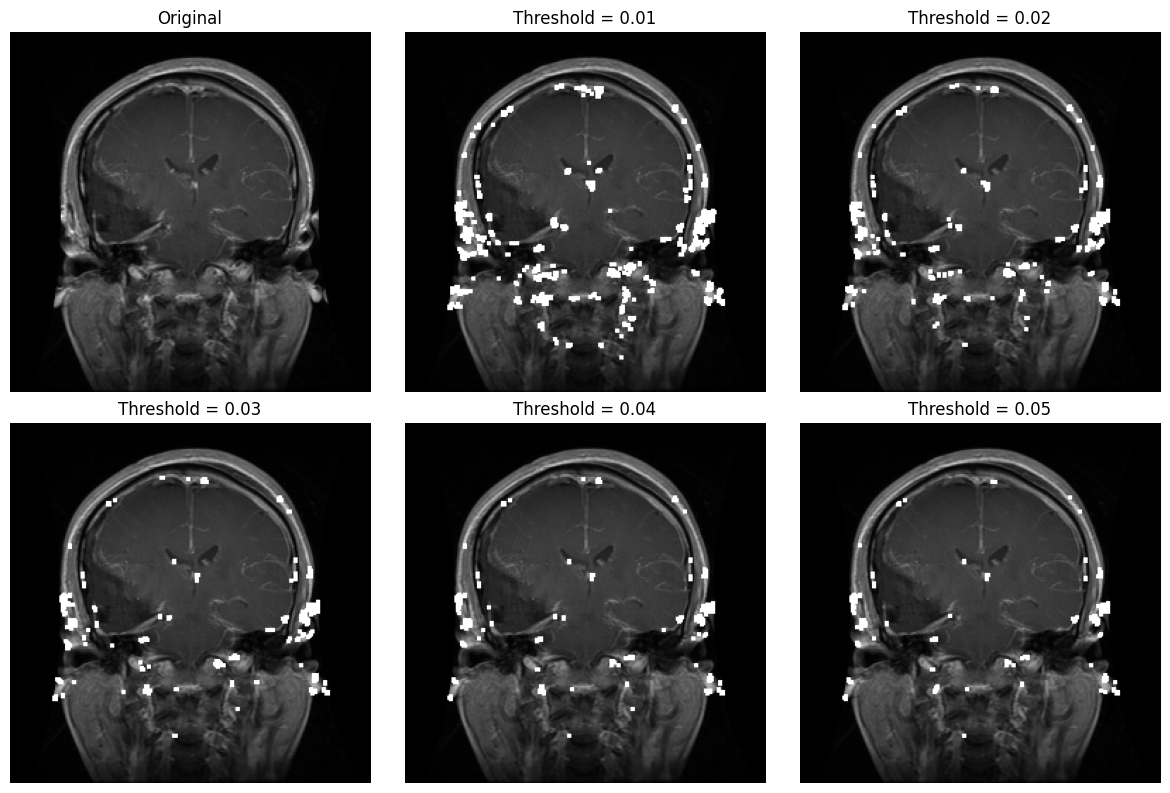

In [ ]:
img = X_train[0]

thresholds = [0.01, 0.02, 0.03, 0.04, 0.05]
# low threshold = accept weak corners
# high threshold = accept only strong corners

plt.figure(figsize=(12, 8))

# show original once
plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

# apply Harris for each threshold
for i, t in enumerate(thresholds, start=2):
    output, harris_map = apply_harris(img, threshold=t)

    plt.subplot(2, 3, i)
    plt.imshow(output, cmap="gray")
    plt.title(f"Threshold = {t}")
    plt.axis("off")

plt.tight_layout()
plt.show()